In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import matplotlib.patches as mpatches
import time

import collections
from collections import Counter

import warnings
warnings.filterwarnings("ignore")

In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data"
column_names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
                'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']

df = pd.read_csv(url, names=column_names)

In [5]:
df.head()


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
df.describe()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


In [6]:
sex_mapping = {'M': 0, 'F': 1, 'I': 2}
df['Sex'] = df['Sex'].map(sex_mapping)

In [7]:

df['AgeGroup'] = (df['Rings'] >= 10).astype(int)
y = df['AgeGroup']
X = df.drop(['Rings', 'AgeGroup'], axis=1)

In [8]:
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,AgeGroup
0,0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,1
1,0,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0
2,1,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,0
3,0,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,1
4,2,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,0


In [9]:
print('Молодые', round(df['AgeGroup'].value_counts()[0]/len(df) * 100,2), '% данных')
print('Старые', round(df['AgeGroup'].value_counts()[1]/len(df) * 100,2), '% данных')

Молодые 50.18 % данных
Старые 49.82 % данных


In [10]:
# df['AgeGroup'].value_counts()  - возвращает словарик,
# где ключ - уникальные значения в столбце AgeGroup кол-во значений
# value - сколько всего записей имело эти значения
print(df['AgeGroup'].value_counts())

# так как это словарь, то чтобы получить значения, обращаемся по ключу:
print(df['AgeGroup'].value_counts()[0])
print(df['AgeGroup'].value_counts()[1])

AgeGroup
0    2096
1    2081
Name: count, dtype: int64
2096
2081


In [12]:
#  вывод отношения классов целевой переменной, но записанный через f строку

n_trans = round(df['AgeGroup'].value_counts()[0]/len(df) * 100,2)
f_trans = round(df['AgeGroup'].value_counts()[1]/len(df) * 100,2)

print(f'Обычные транзакции составляют  {n_trans} % данных')
print(f'Мошеннические транзакции составляют  {f_trans} % данных')

Обычные транзакции составляют  50.18 % данных
Мошеннические транзакции составляют  49.82 % данных


В данном случае датасет сбалансирован

Text(0.5, 1.0, 'Распределение классов \n (0: молодой || 1: старый)')

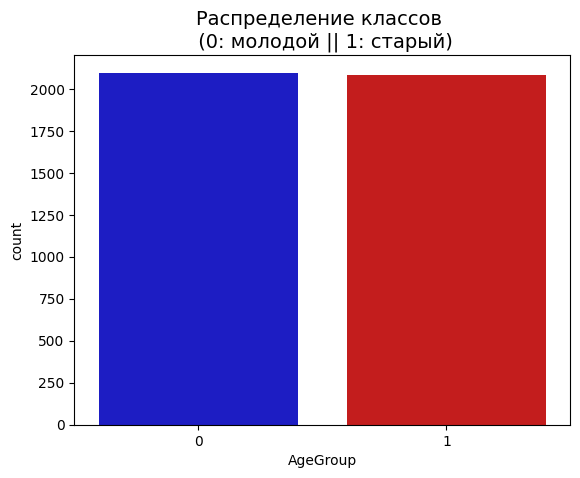

In [13]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='AgeGroup', data=df, palette=colors) # строим гистограмму целевой переменной
plt.title('Распределение классов \n (0: молодой || 1: старый)', fontsize=14)

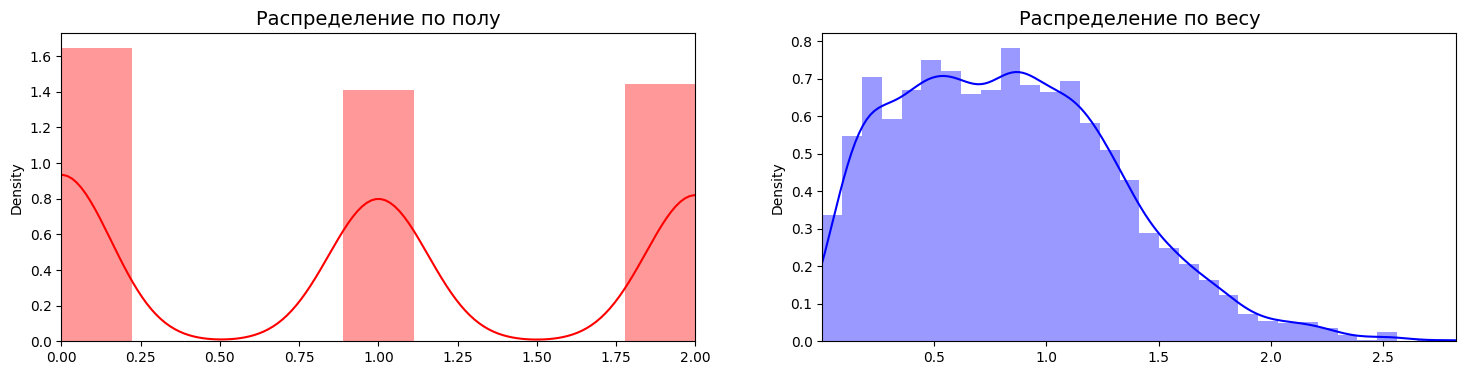

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))

amount_val = df['Sex'].values
time_val = df['Whole_weight'].values

# ВАШ КОД ЗДЕСЬ # строим график распределения суммы транзакций
sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Распределение по полу', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])


# ВАШ КОД ЗДЕСЬ # строим график распределения времени транзакций
sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Распределение по весу', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])

plt.show()

In [26]:
from sklearn.model_selection import train_test_split
# Поскольку большая часть наших данных уже масштабирована, мы должны масштабировать столбцы,
# которые остались (Amount и Time)
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler() # Менее чувствителен к выбросам, чем просто стандартизация

X = df.drop('AgeGroup', axis=1)
y = df['AgeGroup']

original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2,
                                                                                    random_state = 42)


# Посмотрим, какие типы данных возвращаются после разделения:
rt_tmp = original_Xtrain['Sex']
print (f'Тип данных original_Xtrain["Sex"] {type(rt_tmp)}')
print (f'Тип данных original_Xtrain["Sex"].values {type(rt_tmp.values)}')
print (f'Данные original_Xtrain["Sex"].values {rt_tmp.values}')
print (f'Тип данных original_Xtrain["Sex"].values.reshape(-1,1) {type(rt_tmp.values.reshape(-1,1))}')
print (f'Данные original_Xtrain["Sex"].values.reshape(-1,1) \n{rt_tmp.values.reshape(-1,1)} \n')

# вот последнее представление - как раз то, что нужно для RobustScaler . Преобразовываем так нужные все нужные столбцы.

original_Xtrain['scaled_Sex'] = rob_scaler.fit_transform(original_Xtrain['Sex'].values.reshape(-1,1))
original_Xtest['scaled_Sex'] = rob_scaler.fit_transform(original_Xtest['Sex'].values.reshape(-1,1))

original_Xtrain['scaled_Whole_weight'] = rob_scaler.fit_transform(original_Xtrain['Whole_weight'].values.reshape(-1,1))
original_Xtest['scaled_Whole_weight'] = rob_scaler.fit_transform(original_Xtest['Whole_weight'].values.reshape(-1,1))

original_Xtrain.drop(['Whole_weight','Sex'], axis=1, inplace=True)
original_Xtest.drop(['Whole_weight','Sex'], axis=1, inplace=True)

original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values

train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)

print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label/ len(original_ytrain))
print("Тестовый набор:", test_counts_label/ len(original_ytest))

Тип данных original_Xtrain["Sex"] <class 'pandas.core.series.Series'>
Тип данных original_Xtrain["Sex"].values <class 'numpy.ndarray'>
Данные original_Xtrain["Sex"].values [2 2 1 ... 0 0 1]
Тип данных original_Xtrain["Sex"].values.reshape(-1,1) <class 'numpy.ndarray'>
Данные original_Xtrain["Sex"].values.reshape(-1,1) 
[[2]
 [2]
 [1]
 ...
 [0]
 [0]
 [1]] 

Распределение классов: 

Обучающий набор: [0.5013469 0.4986531]
Тестовый набор: [0.50358852 0.49641148]


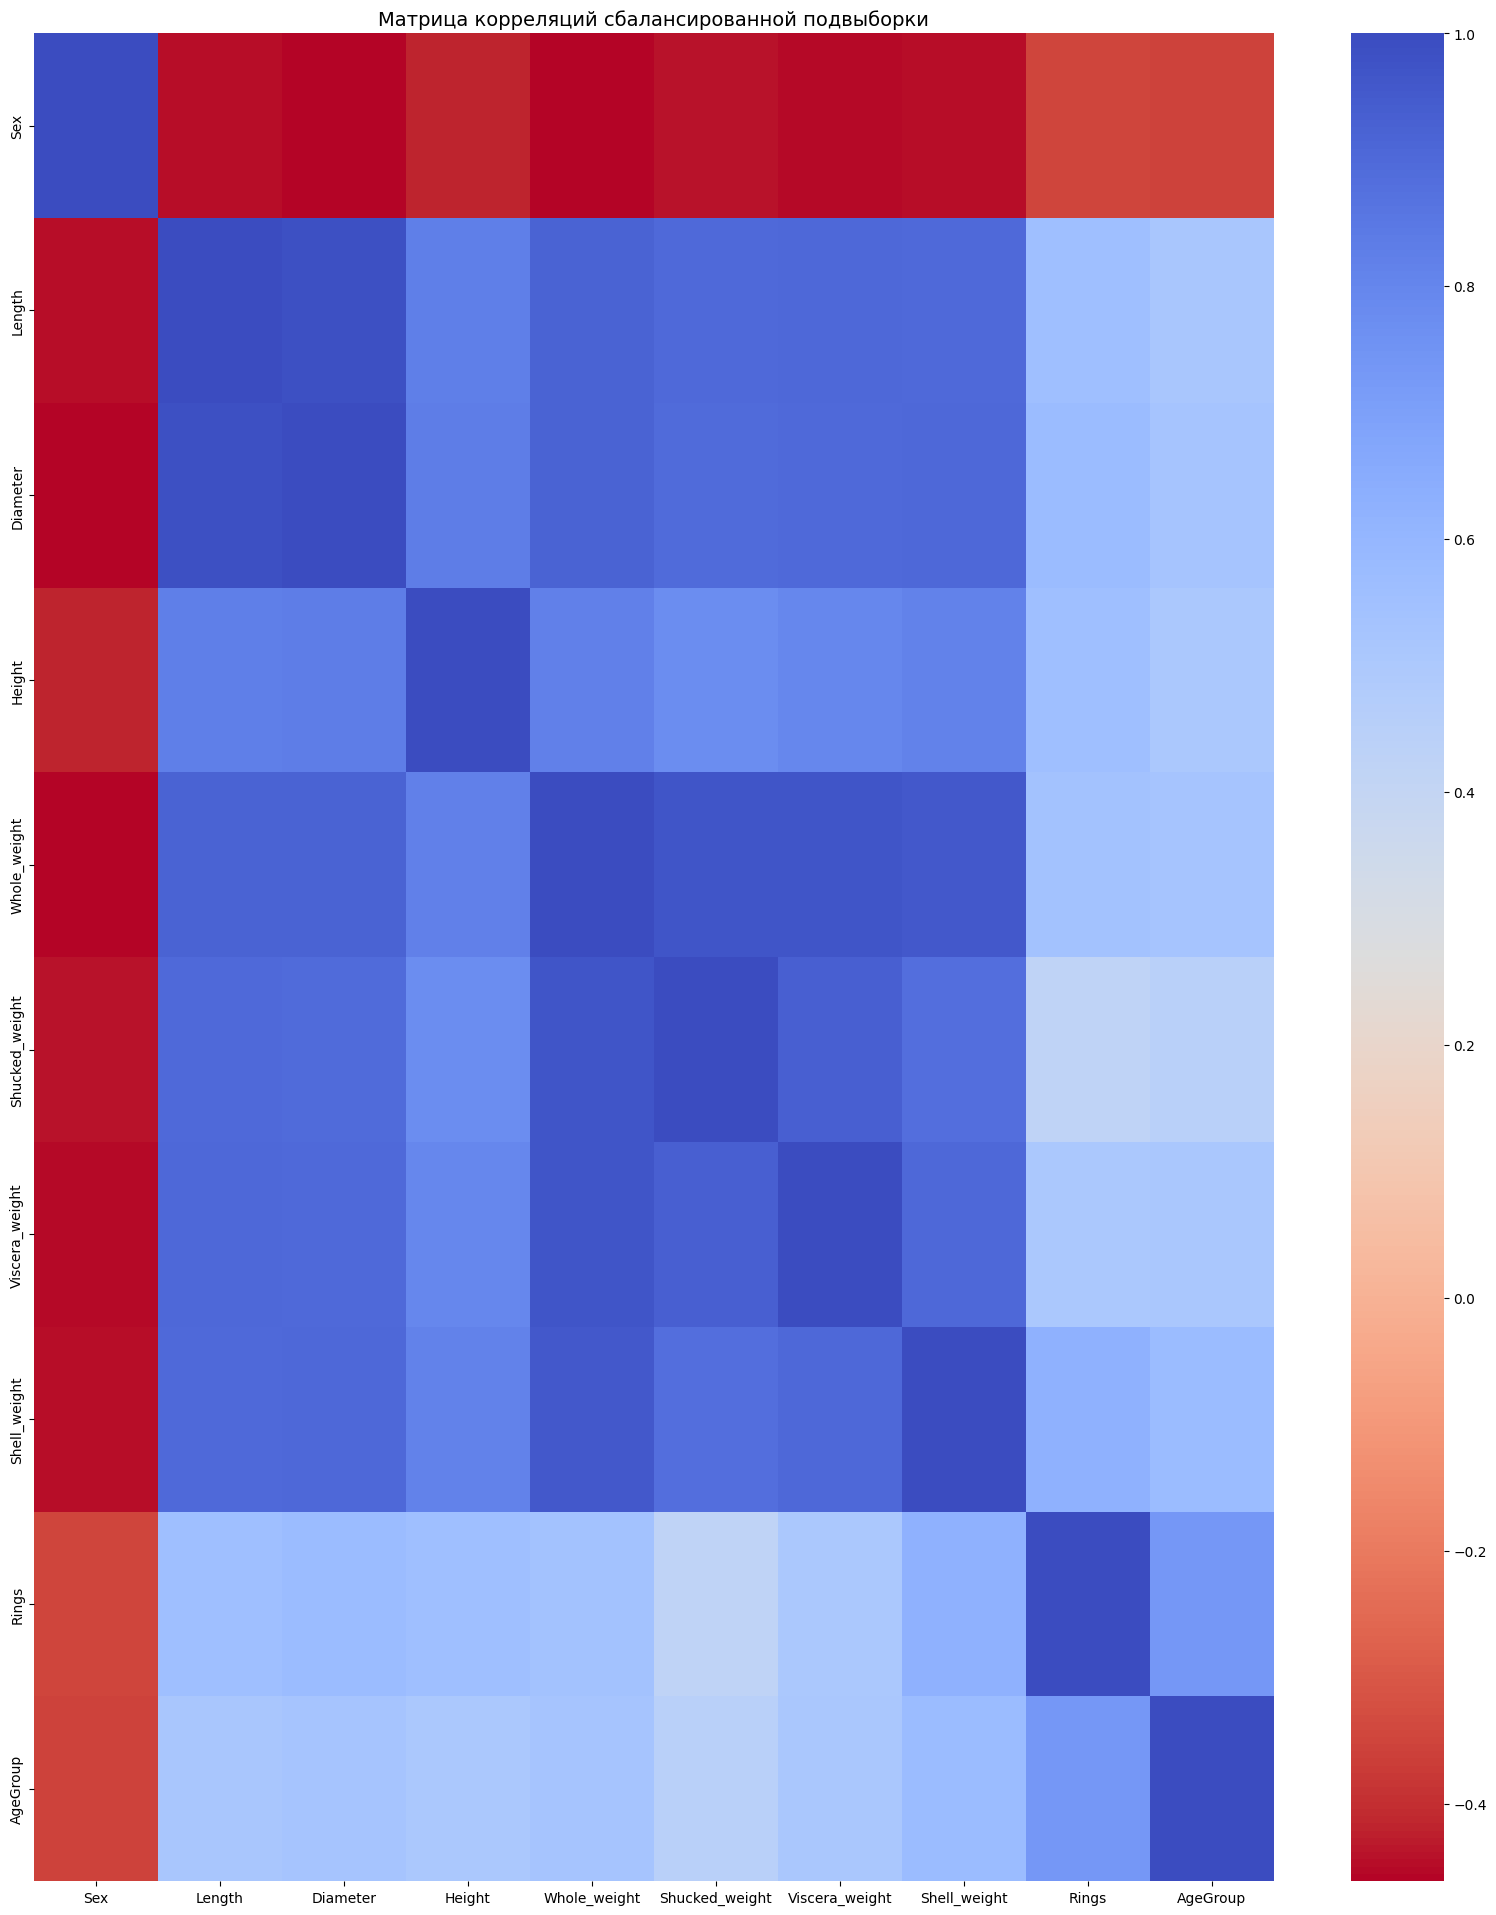

In [28]:
f, ax = plt.subplots(1, 1, figsize=(20, 24))

# Построим матрицу корреляций

sub_sample_corr = df.corr()
sns.heatmap(sub_sample_corr, cmap = 'coolwarm_r', annot_kws ={'size':20}, ax=ax)
ax.set_title('Матрица корреляций сбалансированной подвыборки', fontsize=14)
plt.show()

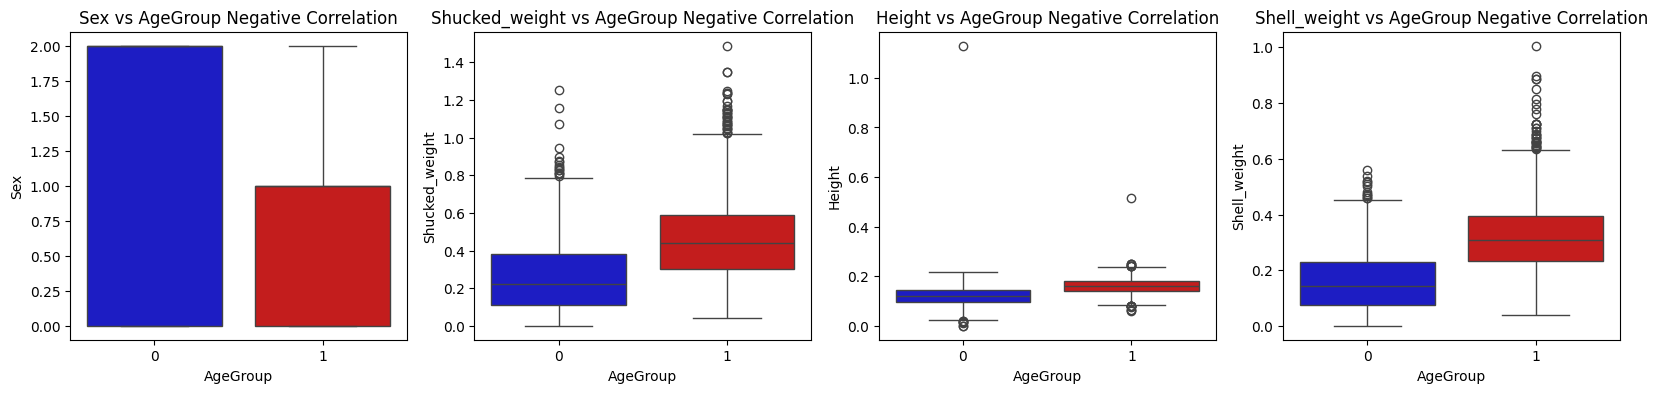

In [36]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))

#
sns.boxplot(x='AgeGroup', y='Sex', data=df, palette=colors, ax=axes[0])
axes[0].set_title('Sex vs AgeGroup Negative Correlation')

#
sns.boxplot(x='AgeGroup', y='Shucked_weight', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Shucked_weight vs AgeGroup Negative Correlation')

#
sns.boxplot(x='AgeGroup', y='Height', data=df, palette=colors, ax=axes[2])
axes[2].set_title('Height vs AgeGroup Negative Correlation')

#
sns.boxplot(x='AgeGroup', y='Shell_weight', data=df, palette=colors, ax=axes[3])
axes[3].set_title('Shell_weight vs AgeGroup Negative Correlation')

plt.show()

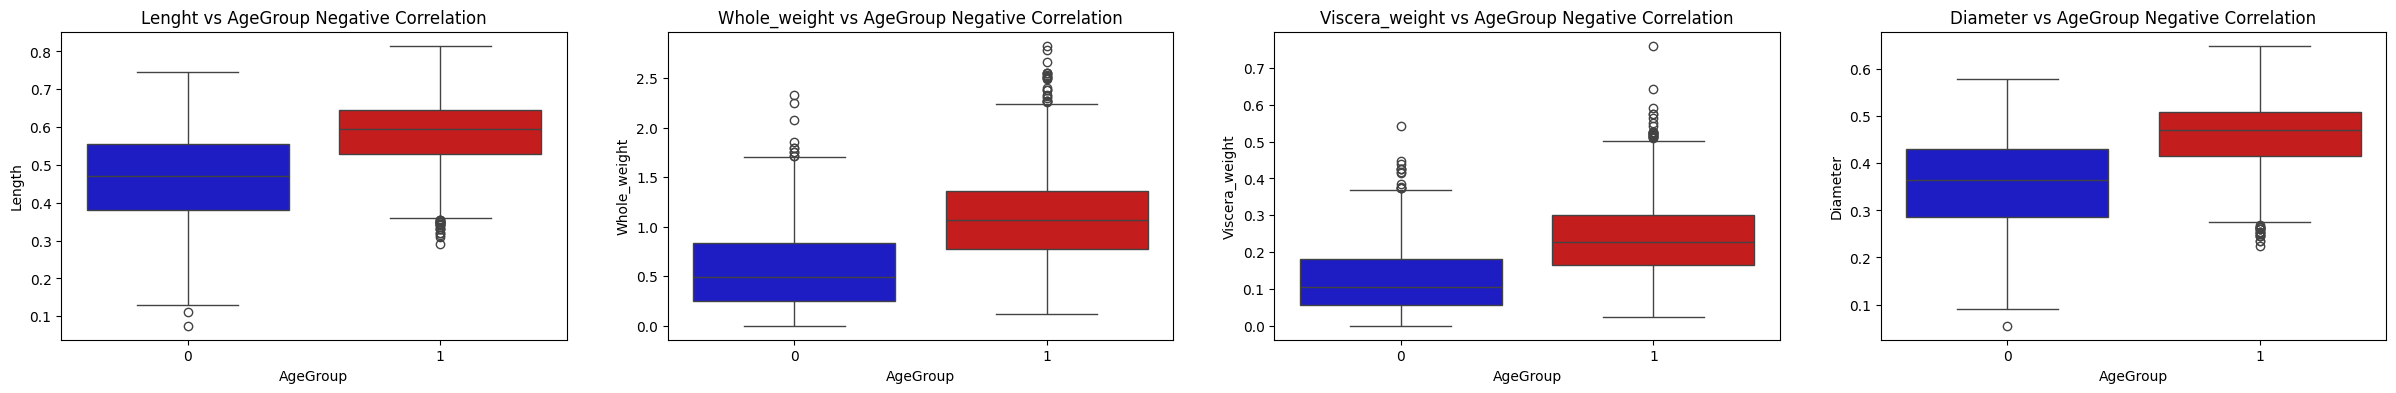

In [37]:
f, axes = plt.subplots(ncols=4, figsize=(30,4))

#
sns.boxplot(x='AgeGroup', y='Length', data=df, palette=colors, ax=axes[0])
axes[0].set_title('Lenght vs AgeGroup Negative Correlation')
#
sns.boxplot(x='AgeGroup', y='Whole_weight', data=df, palette=colors, ax=axes[1])
axes[1].set_title('Whole_weight vs AgeGroup Negative Correlation')
#
sns.boxplot(x='AgeGroup', y='Viscera_weight', data=df, palette=colors, ax=axes[2])
axes[2].set_title('Viscera_weight vs AgeGroup Negative Correlation')
#
sns.boxplot(x='AgeGroup', y='Diameter', data=df, palette=colors, ax=axes[3])
axes[3].set_title('Diameter vs AgeGroup Negative Correlation')
plt.show()

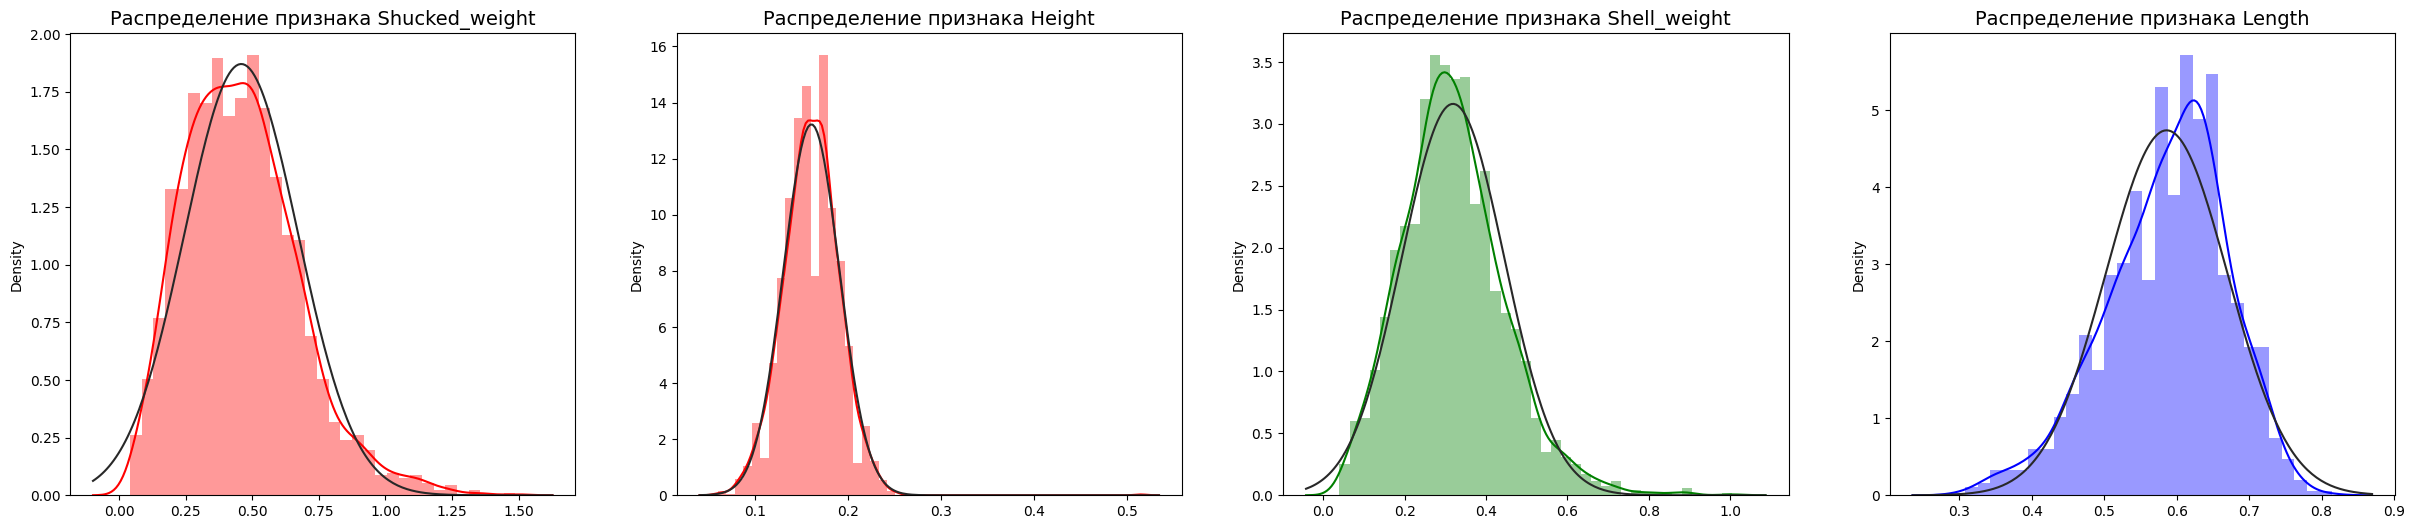

In [38]:
# Строим распределения

from scipy.stats import norm

f, (ax1, ax2, ax3, ax4) = plt.subplots(1,4, figsize=(30, 6))

####
v17_fraud_dist = df['Shucked_weight'].loc[df['AgeGroup'] == 1].values

sns.distplot(v17_fraud_dist, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение признака Shucked_weight', fontsize=14)

####
v14_fraud_dist = df['Height'].loc[df['AgeGroup'] == 1].values

sns.distplot(v14_fraud_dist, ax=ax2, fit=norm, color='r')
ax2.set_title('Распределение признака Height', fontsize=14)

####
v12_fraud_dist = df['Shell_weight'].loc[df['AgeGroup'] == 1].values

sns.distplot(v12_fraud_dist, ax=ax3, fit=norm, color='g')
ax3.set_title('Распределение признака Shell_weight', fontsize=14)

####
v10_fraud_dist = df['Length'].loc[df['AgeGroup'] == 1].values

sns.distplot(v10_fraud_dist, ax=ax4, fit=norm, color='b')
ax4.set_title('Распределение признака Length', fontsize=14)

plt.show()

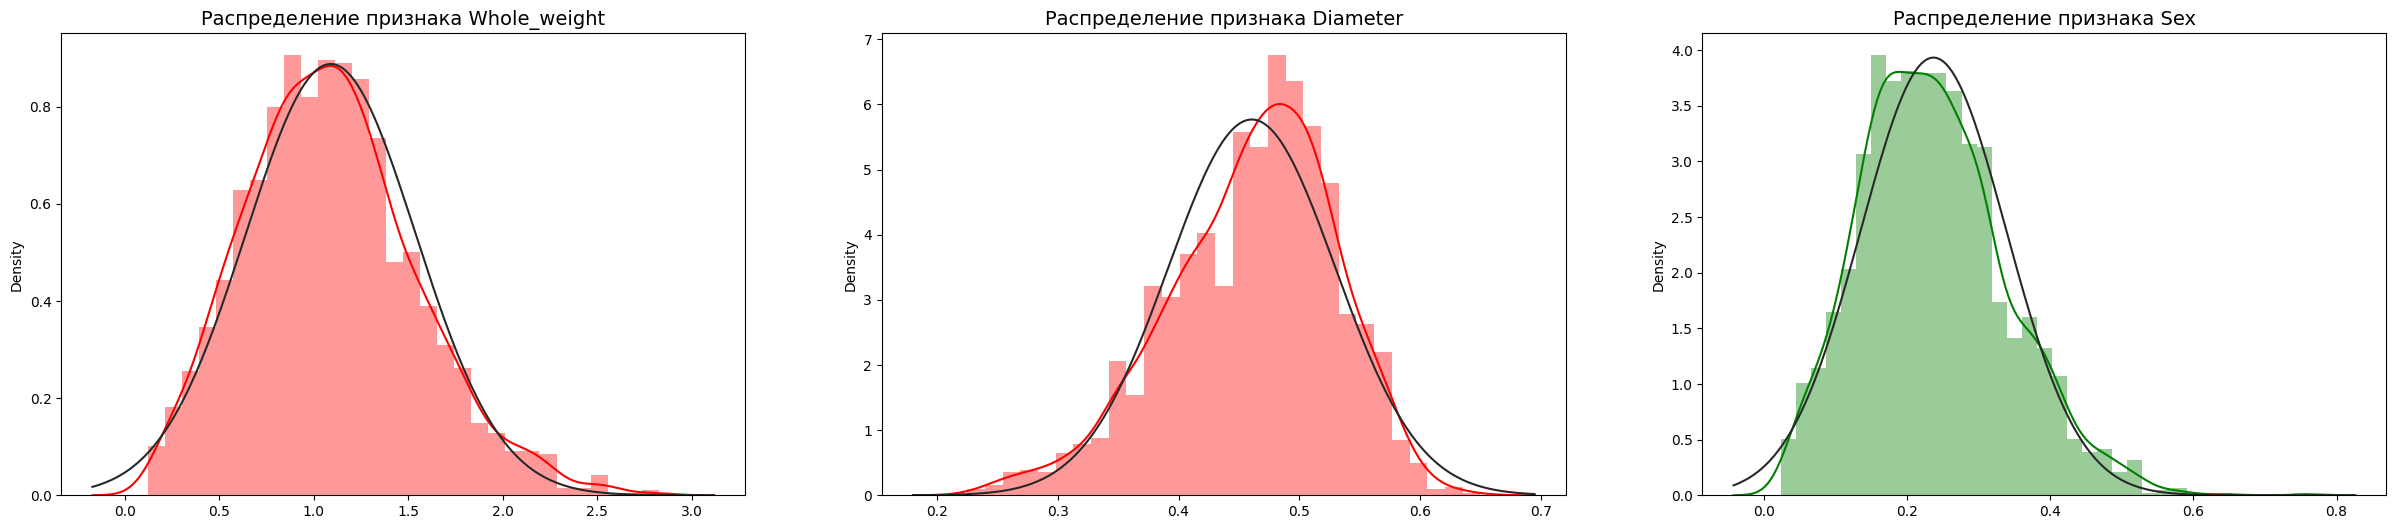

In [42]:
# Строим распределения

from scipy.stats import norm

f, (ax1, ax2, ax3) = plt.subplots(1,3, figsize=(30, 6))

####
v1_fraud_dist = df['Whole_weight'].loc[df['AgeGroup'] == 1].values

sns.distplot(v1_fraud_dist, ax=ax1, fit=norm, color='r')
ax1.set_title('Распределение признака Whole_weight', fontsize=14)

####
v2_fraud_dist = df['Diameter'].loc[df['AgeGroup'] == 1].values

sns.distplot(v2_fraud_dist, ax=ax2, fit=norm, color='r')
ax2.set_title('Распределение признака Diameter', fontsize=14)

####
v3_fraud_dist = df['Viscera_weight'].loc[df['AgeGroup'] == 1].values

sns.distplot(v3_fraud_dist, ax=ax3, fit=norm, color='g')
ax3.set_title('Распределение признака Sex', fontsize=14)


plt.show()

In [47]:
# Удаление выбросов из признака V17
v17_fraud = df['Shucked_weight'].loc[df['AgeGroup'] == 1].values
q25, q75 = np.percentile(v17_fraud, 25), np.percentile(v17_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v17_iqr = q75 - q25
print('iqr: {}'.format(v17_iqr))

v17_cut_off = v17_iqr * 1.5
v17_lower, v17_upper = q25 - v17_cut_off, q75 + v17_cut_off
print('Порог: {}'.format(v17_cut_off))
print('Shucked_weigh нижняя граница: {}'.format(v17_lower))
print('Shucked_weigh верхняя граница: {}'.format(v17_upper))

outliers = [x for x in v17_fraud if x < v17_lower or x > v17_upper]
print('Количество выбросов: {}'.format(len(outliers)))

df_without_outliers  = df.drop(df[(df['Shucked_weight'] > v17_upper) | (df['Shucked_weight'] < v17_lower)].index)
print('----' * 44)



####
# Удаление выбросов из признака V14
v14_fraud = df['Height'].loc[df['AgeGroup'] == 1].values
q25, q75 = np.percentile(v14_fraud, 25), np.percentile(v14_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v14_iqr = q75 - q25
print('iqr: {}'.format(v14_iqr))

v14_cut_off = v14_iqr * 1.5
v14_lower, v14_upper = q25 - v14_cut_off, q75 + v14_cut_off
print('Порог: {}'.format(v14_cut_off))
print('Height нижняя граница: {}'.format(v14_lower))
print('Height верхняя граница: {}'.format(v14_upper))

outliers = [x for x in v14_fraud if x < v14_lower or x > v14_upper]
print('Количество выбросов: {}'.format(len(outliers)))

df_without_outliers  = df.drop(df[(df['Height'] > v14_upper) | (df['Height'] < v14_lower)].index)
print('----' * 44)



####
# Удаление выбросов из признака V12
v12_fraud = df['Shell_weight'].loc[df['AgeGroup'] == 1].values
q25, q75 = np.percentile(v12_fraud, 25), np.percentile(v12_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v12_iqr = q75 - q25
print('iqr: {}'.format(v12_iqr))

v12_cut_off = v12_iqr * 1.5
v12_lower, v12_upper = q25 - v12_cut_off, q75 + v12_cut_off
print('Порог: {}'.format(v12_cut_off))
print('Shell_weight нижняя граница: {}'.format(v12_lower))
print('Shell_weight верхняя граница: {}'.format(v12_upper))
outliers = [x for x in v12_fraud if x < v12_lower or x > v12_upper]
print('Количество выбросов: {}'.format(len(outliers)))
df_without_outliers  = df_without_outliers.drop(df_without_outliers[(df_without_outliers['Shell_weight'] > v12_upper) | (df_without_outliers['Shell_weight'] < v12_lower)].index)
print('----' * 44)


####
# Удаление выбросов из признака V10
v10_fraud = df['Length'].loc[df['AgeGroup'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v10_iqr = q75 - q25
print('iqr: {}'.format(v10_iqr))

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('Порог: {}'.format(v10_cut_off))
print('Length нижняя граница: {}'.format(v10_lower))
print('Length верхняя граница: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('Количество выбросов: {}'.format(len(outliers)))
df_without_outliers  = df_without_outliers.drop(df_without_outliers[(df_without_outliers['Length'] > v10_upper) | (df_without_outliers['Length'] < v10_lower)].index)
print('----' * 44)

####
# Удаление выбросов из признака V1
v10_fraud = df['Whole_weight'].loc[df['AgeGroup'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v10_iqr = q75 - q25
print('iqr: {}'.format(v10_iqr))

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('Порог: {}'.format(v10_cut_off))
print('Whole_weight нижняя граница: {}'.format(v10_lower))
print('Whole_weight верхняя граница: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('Количество выбросов: {}'.format(len(outliers)))
df_without_outliers  = df_without_outliers.drop(df_without_outliers[(df_without_outliers['Whole_weight'] > v10_upper) | (df_without_outliers['Whole_weight'] < v10_lower)].index)
print('----' * 44)

####
# Удаление выбросов из признака V2
v10_fraud = df['Diameter'].loc[df['AgeGroup'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v10_iqr = q75 - q25
print('iqr: {}'.format(v10_iqr))

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('Порог: {}'.format(v10_cut_off))
print('Diameter нижняя граница: {}'.format(v10_lower))
print('Diameter верхняя граница: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('Количество выбросов: {}'.format(len(outliers)))
df_without_outliers  = df_without_outliers.drop(df_without_outliers[(df_without_outliers['Diameter'] > v10_upper) | (df_without_outliers['Diameter'] < v10_lower)].index)
print('----' * 44)
####
# Удаление выбросов из признака V3
v10_fraud = df['Viscera_weight'].loc[df['AgeGroup'] == 1].values
q25, q75 = np.percentile(v10_fraud, 25), np.percentile(v10_fraud, 75)
print('Квартиль 25: {} | Квартиль 75: {}'.format(q25, q75))
v10_iqr = q75 - q25
print('iqr: {}'.format(v10_iqr))

v10_cut_off = v10_iqr * 1.5
v10_lower, v10_upper = q25 - v10_cut_off, q75 + v10_cut_off
print('Порог: {}'.format(v10_cut_off))
print('Viscera_weight нижняя граница: {}'.format(v10_lower))
print('Viscera_weight верхняя граница: {}'.format(v10_upper))
outliers = [x for x in v10_fraud if x < v10_lower or x > v10_upper]
print('Количество выбросов: {}'.format(len(outliers)))
df_without_outliers  = df_without_outliers.drop(df_without_outliers[(df_without_outliers['Viscera_weight'] > v10_upper) | (df_without_outliers['Viscera_weight'] < v10_lower)].index)

Квартиль 25: 0.3 | Квартиль 75: 0.5875
iqr: 0.28750000000000003
Порог: 0.43125
Shucked_weigh нижняя граница: -0.13125000000000003
Shucked_weigh верхняя граница: 1.01875
Количество выбросов: 34
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 0.14 | Квартиль 75: 0.18
iqr: 0.03999999999999998
Порог: 0.05999999999999997
Height нижняя граница: 0.08000000000000004
Height верхняя граница: 0.23999999999999996
Количество выбросов: 18
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Квартиль 25: 0.235 | Квартиль 75: 0.394
iqr: 0.15900000000000003
Порог: 0.23850000000000005
Shell_weight нижняя граница: -0.0035000000000000586
Shell_weight верхняя граница: 0.6325000000000001
Количество выбросов: 34
-----------------------------------

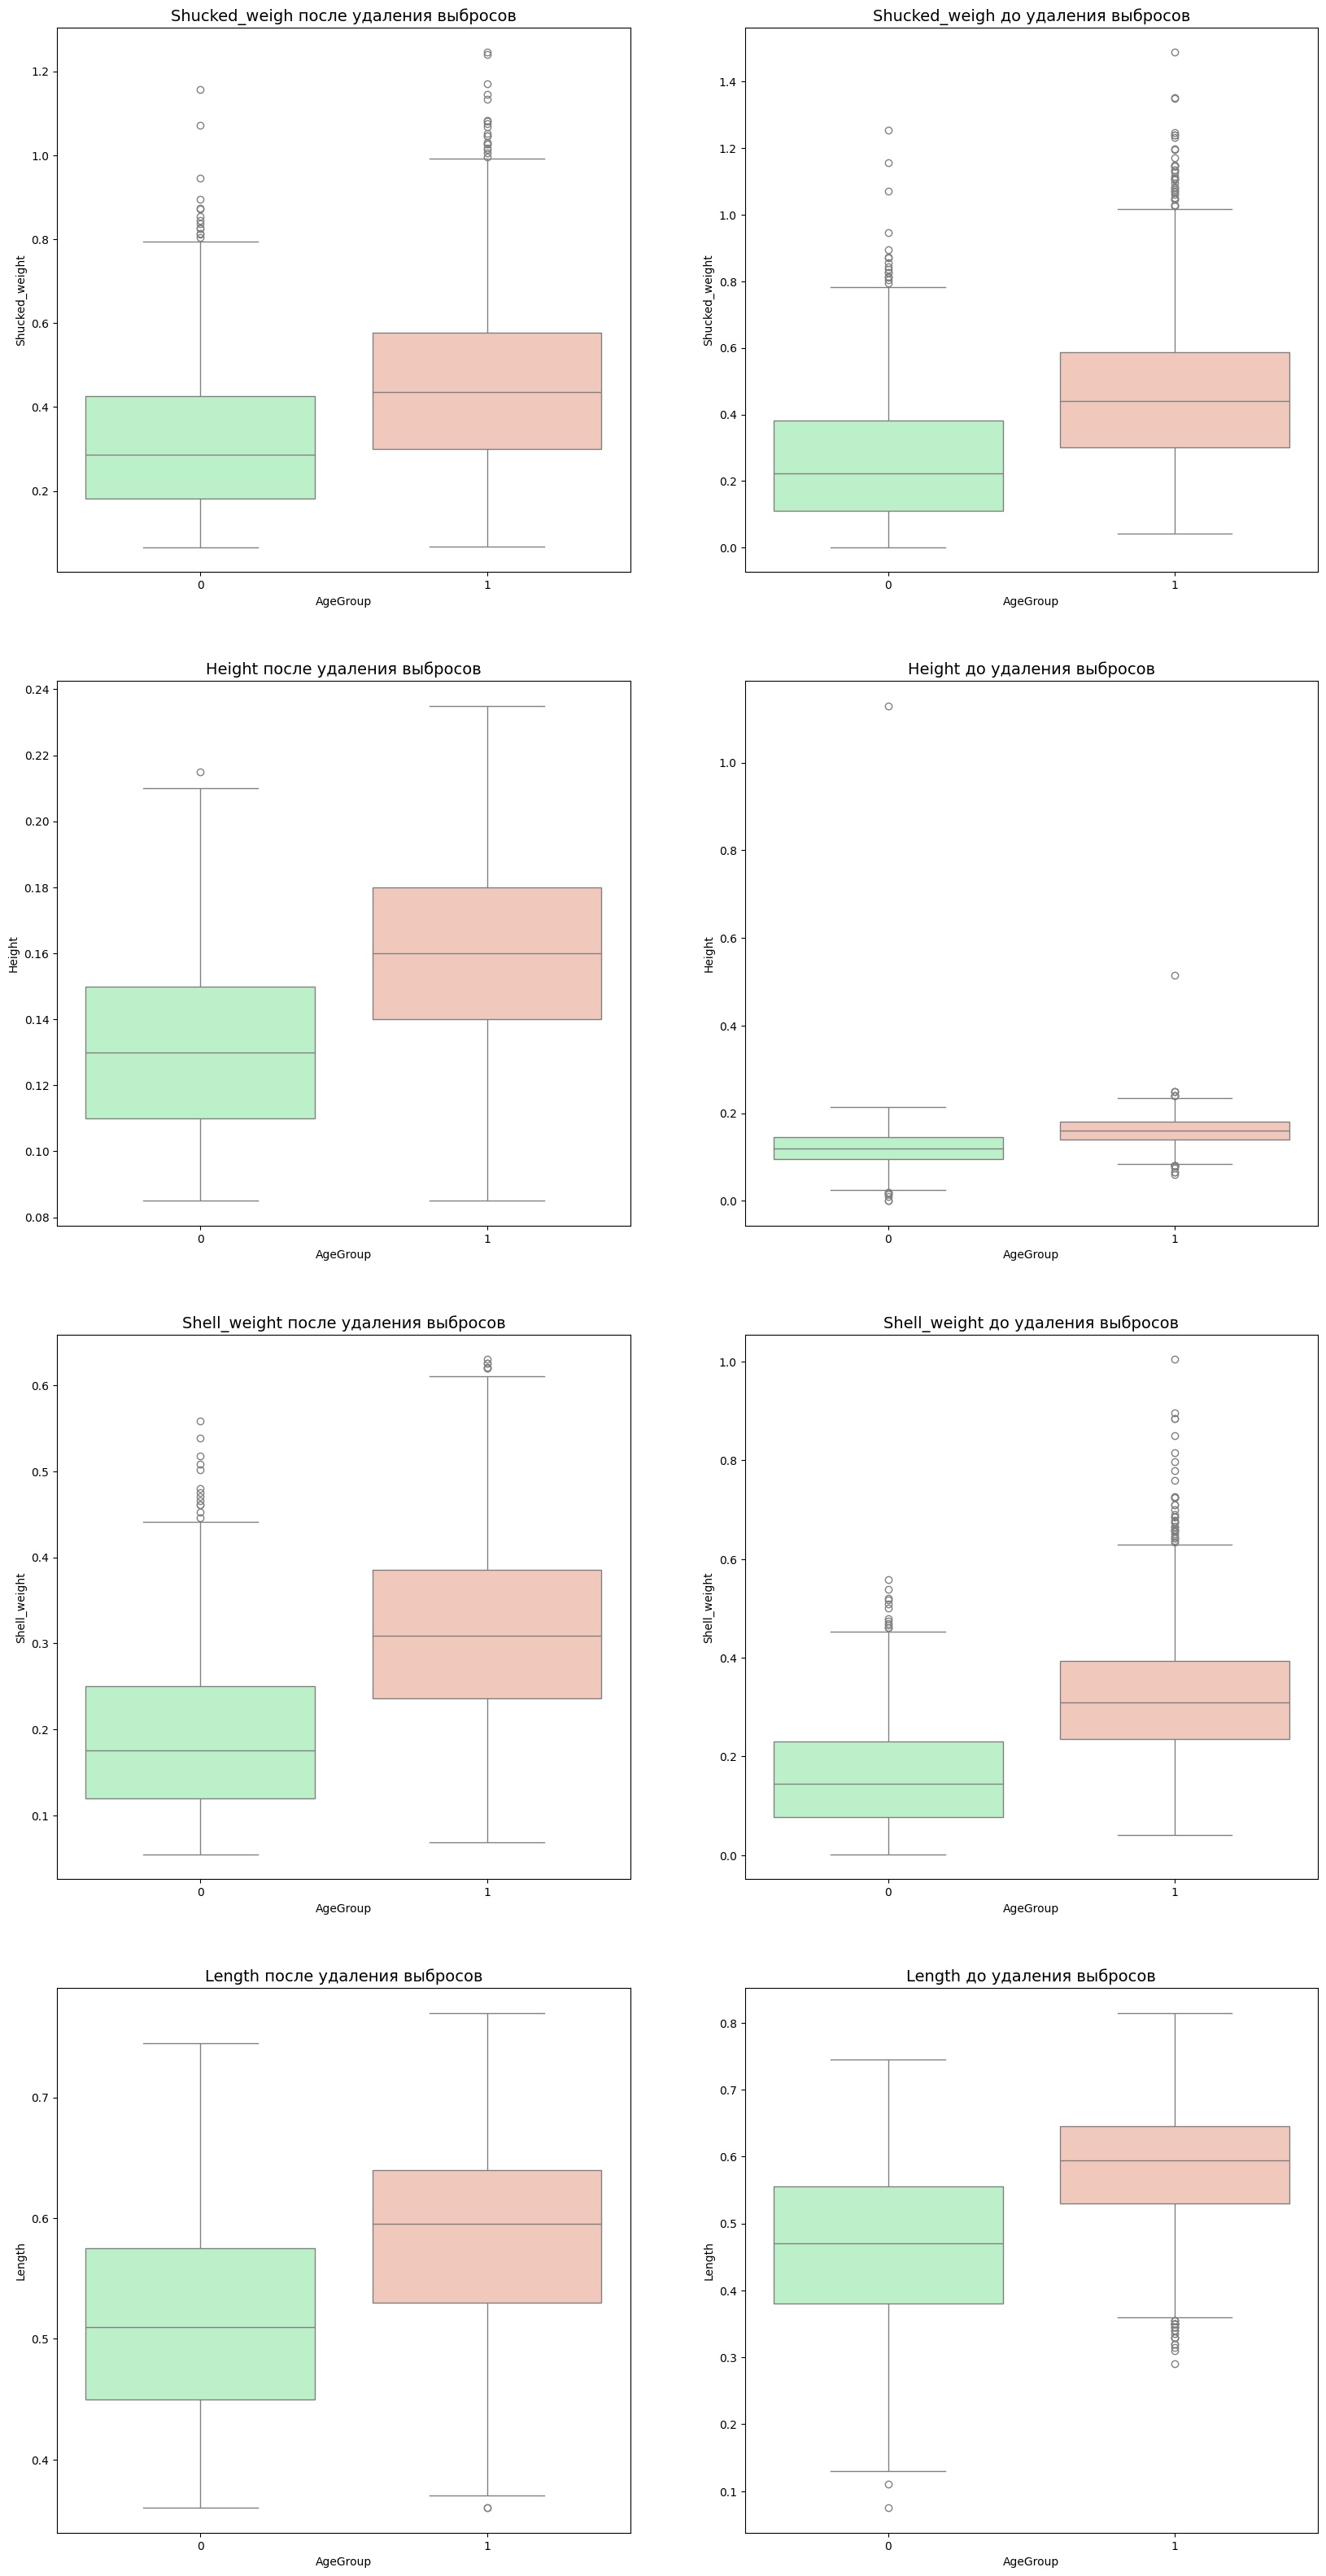

In [62]:
f, ax = plt.subplots(4, 2, figsize=(20,40))

colors = ['#B3F9C5', '#f9c5b3']

# Boxplot для признака V17
sns.boxplot(x="AgeGroup", y="Shucked_weight", data=df_without_outliers,ax=ax[0,0], palette=colors)
ax[0,0].set_title("Shucked_weigh после удаления выбросов", fontsize=14)


# Boxplot для признака V17
sns.boxplot(x="AgeGroup", y="Shucked_weight", data=df,ax=ax[0,1], palette=colors)
ax[0,1].set_title("Shucked_weigh до удаления выбросов", fontsize=14)


# Boxplot для признака V14
sns.boxplot(x="AgeGroup", y="Height", data=df_without_outliers,ax=ax[1,0], palette=colors)
ax[1,0].set_title("Height после удаления выбросов", fontsize=14)


# Boxplot для признака V14
sns.boxplot(x="AgeGroup", y="Height", data=df,ax=ax[1,1], palette=colors)
ax[1,1].set_title("Height до удаления выбросов", fontsize=14)


# Boxplot для признака V12
sns.boxplot(x="AgeGroup", y="Shell_weight", data=df_without_outliers, ax=ax[2,0], palette=colors)
ax[2,0].set_title("Shell_weight после удаления выбросов", fontsize=14)


# Boxplot для признака V12
sns.boxplot(x="AgeGroup", y="Shell_weight", data=df, ax=ax[2,1], palette=colors)
ax[2,1].set_title("Shell_weight до удаления выбросов", fontsize=14)





# Boxplot для признака V10
sns.boxplot(x="AgeGroup", y="Length", data=df_without_outliers, ax=ax[3,0], palette=colors)
ax[3,0].set_title("Length после удаления выбросов", fontsize=14)




# Boxplot для признака V10
sns.boxplot(x="AgeGroup", y="Length", data=df, ax=ax[3,1], palette=colors)
ax[3,1].set_title("Length до удаления выбросов", fontsize=14)



plt.show()

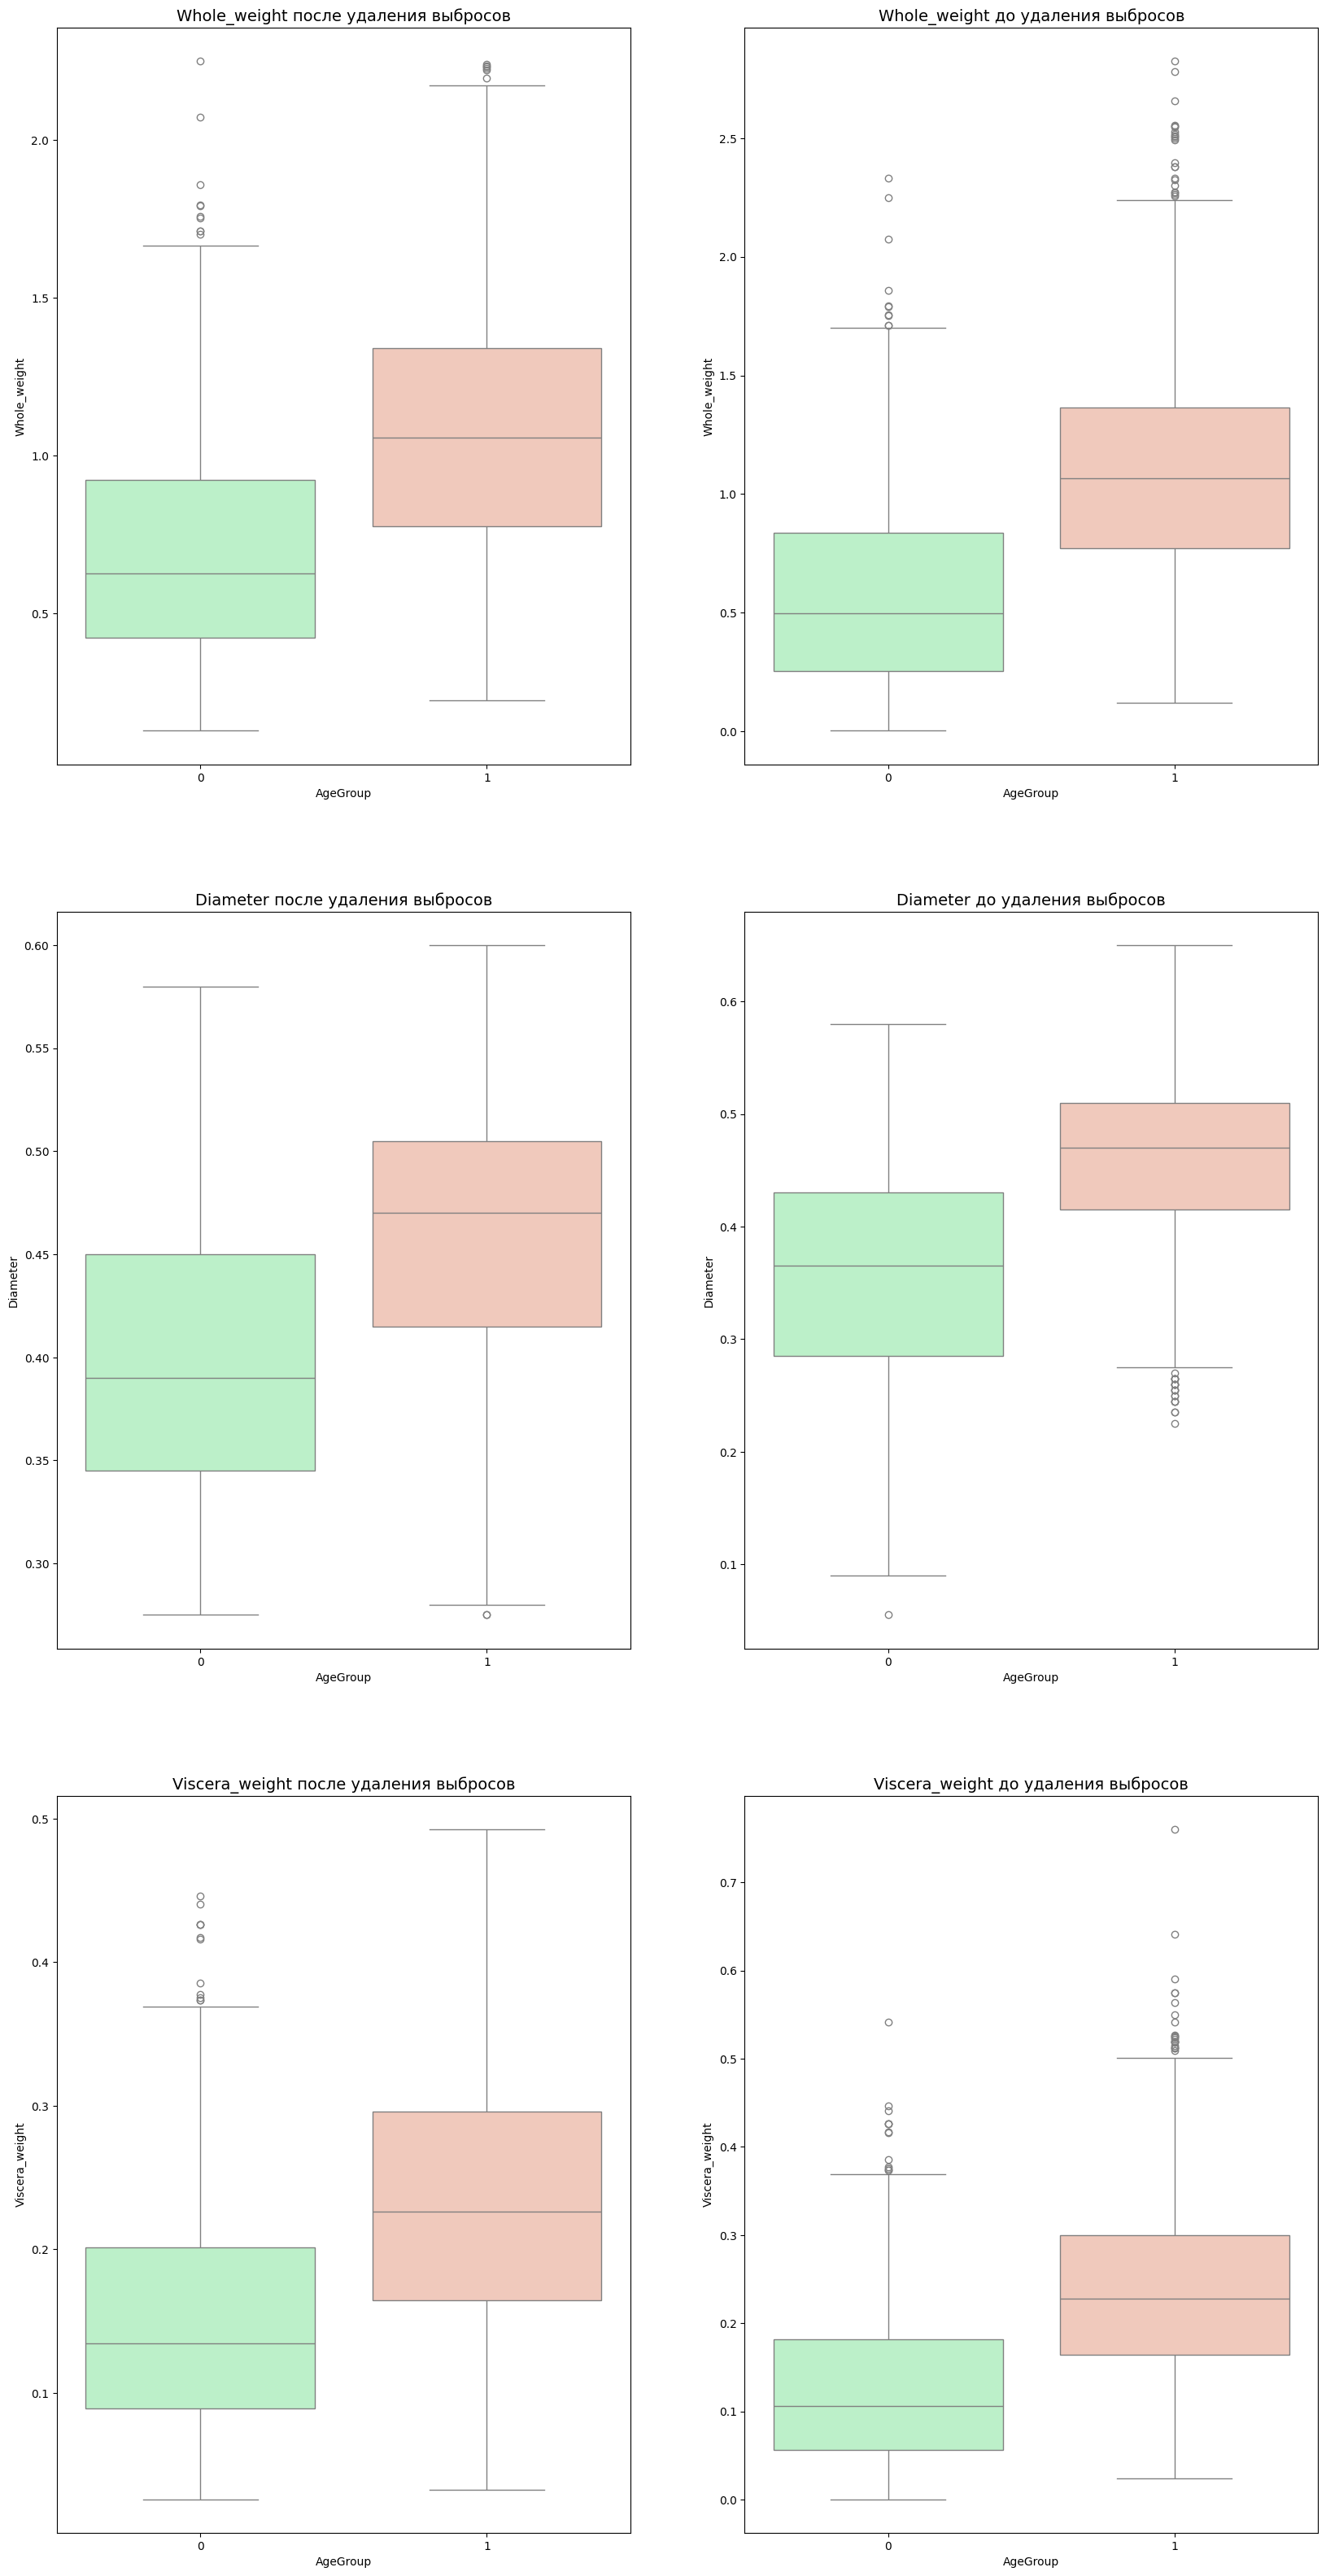

In [61]:
f, ax = plt.subplots(3, 2, figsize=(20,40))
# Boxplot для признака V1
sns.boxplot(x="AgeGroup", y="Whole_weight", data=df_without_outliers, ax=ax[0,0], palette=colors)
ax[0,0].set_title("Whole_weight после удаления выбросов", fontsize=14)




# Boxplot для признака V1
sns.boxplot(x="AgeGroup", y="Whole_weight", data=df, ax=ax[0,1], palette=colors)
ax[0,1].set_title("Whole_weight до удаления выбросов", fontsize=14)



# Boxplot для признака V2
sns.boxplot(x="AgeGroup", y="Diameter", data=df_without_outliers, ax=ax[1,0], palette=colors)
ax[1,0].set_title("Diameter после удаления выбросов", fontsize=14)




# Boxplot для признака V2
sns.boxplot(x="AgeGroup", y="Diameter", data=df, ax=ax[1,1], palette=colors)
ax[1,1].set_title("Diameter до удаления выбросов", fontsize=14)


# Boxplot для признака V3
sns.boxplot(x="AgeGroup", y="Viscera_weight", data=df_without_outliers, ax=ax[2,0], palette=colors)
ax[2,0].set_title("Viscera_weight после удаления выбросов", fontsize=14)




# Boxplot для признака V3
sns.boxplot(x="AgeGroup", y="Viscera_weight", data=df, ax=ax[2,1], palette=colors)
ax[2,1].set_title("Viscera_weight до удаления выбросов", fontsize=14)




plt.show()

In [63]:
new_df = df_without_outliers

In [64]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD

X = new_df.drop('AgeGroup', axis=1)
y = new_df['AgeGroup']



# T-SNE алгоритм
t0 = time.time()
X_reduced_tsne = TSNE(n_components=2, random_state=42).fit_transform(X.values)
# ВАШ КОД ЗДЕСЬ
t1 = time.time()
print("T-SNE заняло {:.2} сек".format(t1 - t0))

# PCA алгоритм
t0 = time.time()
# ВАШ КОД ЗДЕСЬ
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X.values)
t1 = time.time()
print("PCA заняло {:.2} сек".format(t1 - t0))

# TruncatedSVD алгоритм
t0 = time.time()
# ВАШ КОД ЗДЕСЬ
X_reduced_svd = TruncatedSVD(n_components=2, algorithm='randomized', random_state=42).fit_transform(X.values)
t1 = time.time()
print("Truncated SVD заняло {:.2} сек".format(t1 - t0))

T-SNE заняло 4.7e+01 сек
PCA заняло 0.021 сек
Truncated SVD заняло 0.007 сек


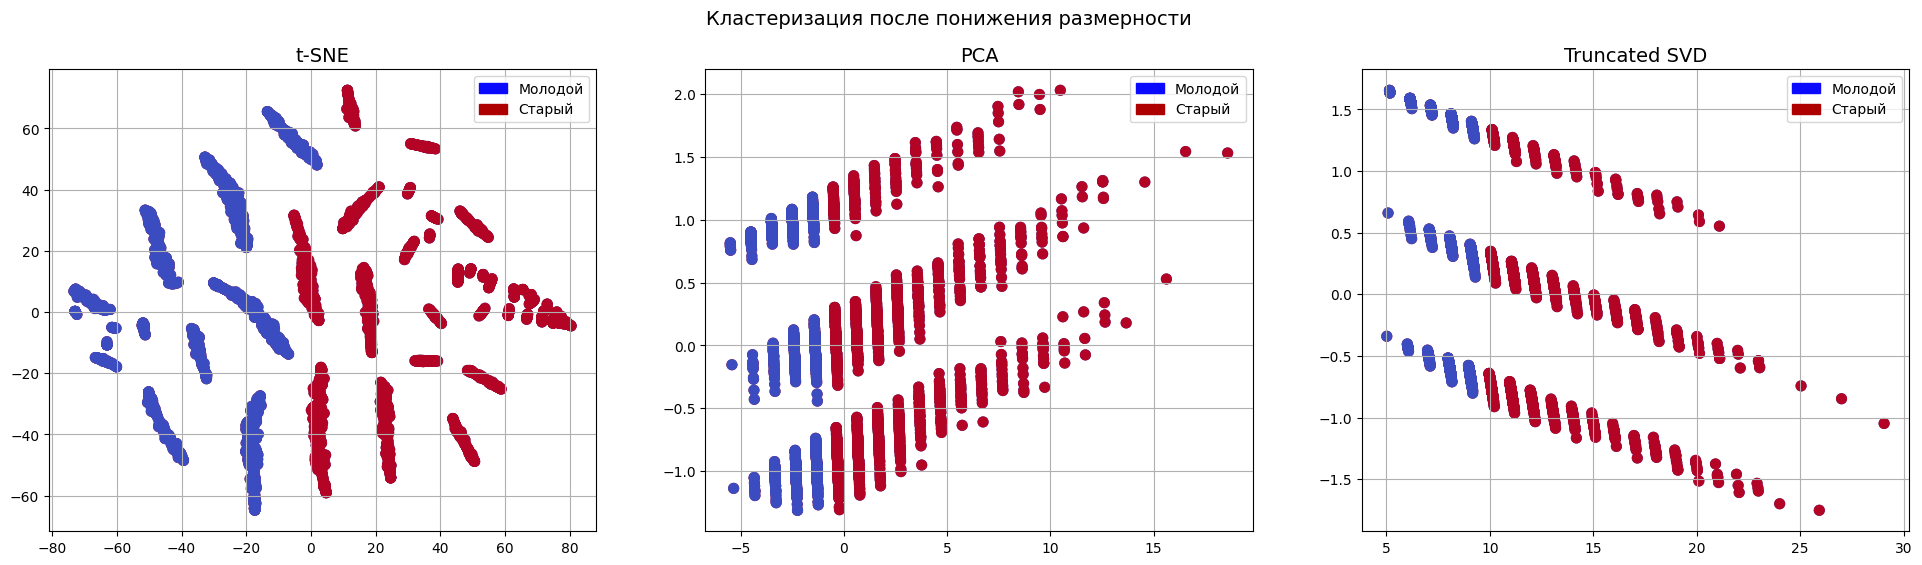

In [66]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24,6))
f.suptitle('Кластеризация после понижения размерности', fontsize=14)


blue_patch = mpatches.Patch(color='#0A0AFF', label='Молодой')
red_patch = mpatches.Patch(color='#AF0000', label='Старый')


# t-SNE scatter plot
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 0), cmap='coolwarm', label='Молодой', linewidths=2)
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=(y == 1), cmap='coolwarm', label='Старый', linewidths=2)
ax1.set_title('t-SNE', fontsize=14)

ax1.grid(True)

ax1.legend(handles=[blue_patch, red_patch])


# PCA scatter plot
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 0), cmap='coolwarm', label='Молодой', linewidths=2)
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=(y == 1), cmap='coolwarm', label='Старый', linewidths=2)
ax2.set_title('PCA', fontsize=14)

ax2.grid(True)

ax2.legend(handles=[blue_patch, red_patch])

# TruncatedSVD scatter plot
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 0), cmap='coolwarm', label='Молодой', linewidths=2)
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=(y == 1), cmap='coolwarm', label='Старый', linewidths=2)
ax3.set_title('Truncated SVD', fontsize=14)

ax3.grid(True)

ax3.legend(handles=[blue_patch, red_patch])

plt.show()

In [82]:
X = new_df.drop('AgeGroup', axis=1)
y = new_df['AgeGroup']

In [83]:
# Про масштабирование мы с вами уже в курсе. Опять используем RobustScaler

from sklearn.model_selection import train_test_split
# Поскольку большая часть наших данных уже масштабирована, мы должны масштабировать столбцы,
# которые остались (Amount и Time)
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42,
                                                    stratify = y)



In [84]:
# Переводим данные в массив для подачи в классификатор
X_train = X_train.values
X_test = X_test.values
y_train = y_train.values
y_test = y_test.values

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Выберем несколько простых моделей из библиотеки sklearn

classifiers = {
    "LogisiticRegression": LogisticRegression(),  # Логистическая регрессия
    "KNearest": SVC(),  # Метод опорных векторов
    "Support Vector Classifier": KNeighborsClassifier(),# Метод ближайших соседей
    "DecisionTreeClassifier": DecisionTreeClassifier() # Решающее дерево
}

In [88]:
from sklearn.model_selection import cross_val_score

for key, classifier in classifiers.items():
    #classifier.fit(X_train, y_train)
    training_score = cross_val_score(classifier, X_train, y_train, cv=5)
    print("Модель ", classifier.__class__.__name__, "получила на обучающей выборке", round(training_score.mean(), 2) * 100, "% accuracy score")

Модель  LogisticRegression получила на обучающей выборке 100.0 % accuracy score
Модель  SVC получила на обучающей выборке 100.0 % accuracy score
Модель  KNeighborsClassifier получила на обучающей выборке 100.0 % accuracy score
Модель  DecisionTreeClassifier получила на обучающей выборке 100.0 % accuracy score


In [89]:
# Используем поиск по сетке для подбора гиперпараметров
from sklearn.model_selection import GridSearchCV

# Логистическая регрессия
log_reg_params = {"penalty": ['l1', 'l2'], 'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

grid_log_reg = GridSearchCV(LogisticRegression(), log_reg_params)
grid_log_reg.fit(X_train, y_train)

# Выбираем лучшую модель
log_reg = grid_log_reg.best_estimator_ #  для Логистическая регрессия

# Метод ближайших соседей
knears_params = {"n_neighbors": list(range(2,7,1)), 'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']}

grid_knears = GridSearchCV(KNeighborsClassifier(), knears_params)
grid_knears.fit(X_train, y_train)

knears_neighbors = grid_knears.best_estimator_# для  K ближайший соседей

# Метод опорных векторов
x = [1.0, 1000.0]
y = [0.9]
z = [4]
svc_params=[
            {'C': x,'kernel': ['rbf'],'gamma': y} ,
            {'C': x,'kernel': ['poly'],'gamma': y,'degree': z}
           ]
grid_svc=GridSearchCV(estimator = SVC(),
                        param_grid = svc_params,
                        scoring='accuracy',
                        cv=3,
                        n_jobs=-1)

grid_svc.fit(X_train, y_train)

svc = grid_svc.best_estimator_#  для SVM

# Решающее дерево
tree_params = {"criterion": ["gini", "entropy"], "max_depth": list(range(2,7,1)),
              "min_samples_leaf": list(range(5,7,1))}
grid_tree = GridSearchCV(DecisionTreeClassifier(), tree_params)
grid_tree.fit(X_train, y_train)

tree_clf = grid_tree.best_estimator_#  для решающий деревьев

In [90]:
# Проверим, как поменялись метрики

log_reg_score = cross_val_score(log_reg, X_train, y_train, cv=5)
print('Logistic Regression Cross Validation Score: ', round(log_reg_score.mean() * 100, 2).astype(str) + '%')


knears_score = cross_val_score(knears_neighbors, X_train, y_train, cv=5)
print('Knears Neighbors Cross Validation Score', round(knears_score.mean() * 100, 2).astype(str) + '%')

svc_score = cross_val_score(svc, X_train, y_train, cv=5)
print('Support Vector Classifier Cross Validation Score', round(svc_score.mean() * 100, 2).astype(str) + '%')

tree_score = cross_val_score(tree_clf, X_train, y_train, cv=5)
print('DecisionTree Classifier Cross Validation Score', round(tree_score.mean() * 100, 2).astype(str) + '%')

Logistic Regression Cross Validation Score:  100.0%
Knears Neighbors Cross Validation Score 100.0%
Support Vector Classifier Cross Validation Score 100.0%
DecisionTree Classifier Cross Validation Score 100.0%


In [75]:
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import learning_curve
import seaborn as sn

In [76]:
def plot_learning_curves(estimator1, estimator2, estimator3, estimator4, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)):
    f, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2,2, figsize=(20,14), sharey=True)
    if ylim is not None:
        plt.ylim(*ylim)

    # Первая модель
    train_sizes, train_scores, test_scores = learning_curve(estimator1, X, y, cv=cv,
                                                            n_jobs=n_jobs, train_sizes=train_sizes)#
    train_scores_mean = np.mean(train_scores, axis=1)#
    train_scores_std = np.std(train_scores, axis=1)#
    test_scores_mean = np.mean(test_scores, axis=1)#
    test_scores_std = np.std(test_scores, axis=1)#
    ax1.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax1.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax1.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax1.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax1.set_title("Logistic Regression Learning Curve", fontsize=14)
    ax1.set_xlabel('Размер выборки')
    ax1.set_ylabel('Score')
    ax1.grid(True)
    ax1.legend(loc="best")

    # Вторая модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator2, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax2.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax2.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax2.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Training score")
    ax2.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax2.set_title("Knears Neighbors Learning Curve", fontsize=14)
    ax2.set_xlabel('Размер выборки')
    ax2.set_ylabel('Score')
    ax2.grid(True)
    ax2.legend(loc="best")


    # Третья модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator3, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax3.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax3.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax3.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Размер выборки")
    ax3.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax3.set_title("Support Vector Classifier \n Learning Curve", fontsize=14)
    ax3.set_xlabel('Training size (m)')
    ax3.set_ylabel('Score')
    ax3.grid(True)
    ax3.legend(loc="best")


    # Четвертая модель
    train_sizes, train_scores, test_scores = learning_curve(
        estimator4, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    ax4.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1,
                     color="#ff9124")
    ax4.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="#2492ff")
    ax4.plot(train_sizes, train_scores_mean, 'o-', color="#ff9124",
             label="Размер выборки")
    ax4.plot(train_sizes, test_scores_mean, 'o-', color="#2492ff",
             label="Cross-validation score")
    ax4.set_title("Decision Tree Classifier \n Learning Curve", fontsize=14)
    ax4.set_xlabel('Training size (m)')
    ax4.set_ylabel('Score')
    ax4.grid(True)
    ax4.legend(loc="best")

    return plt

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

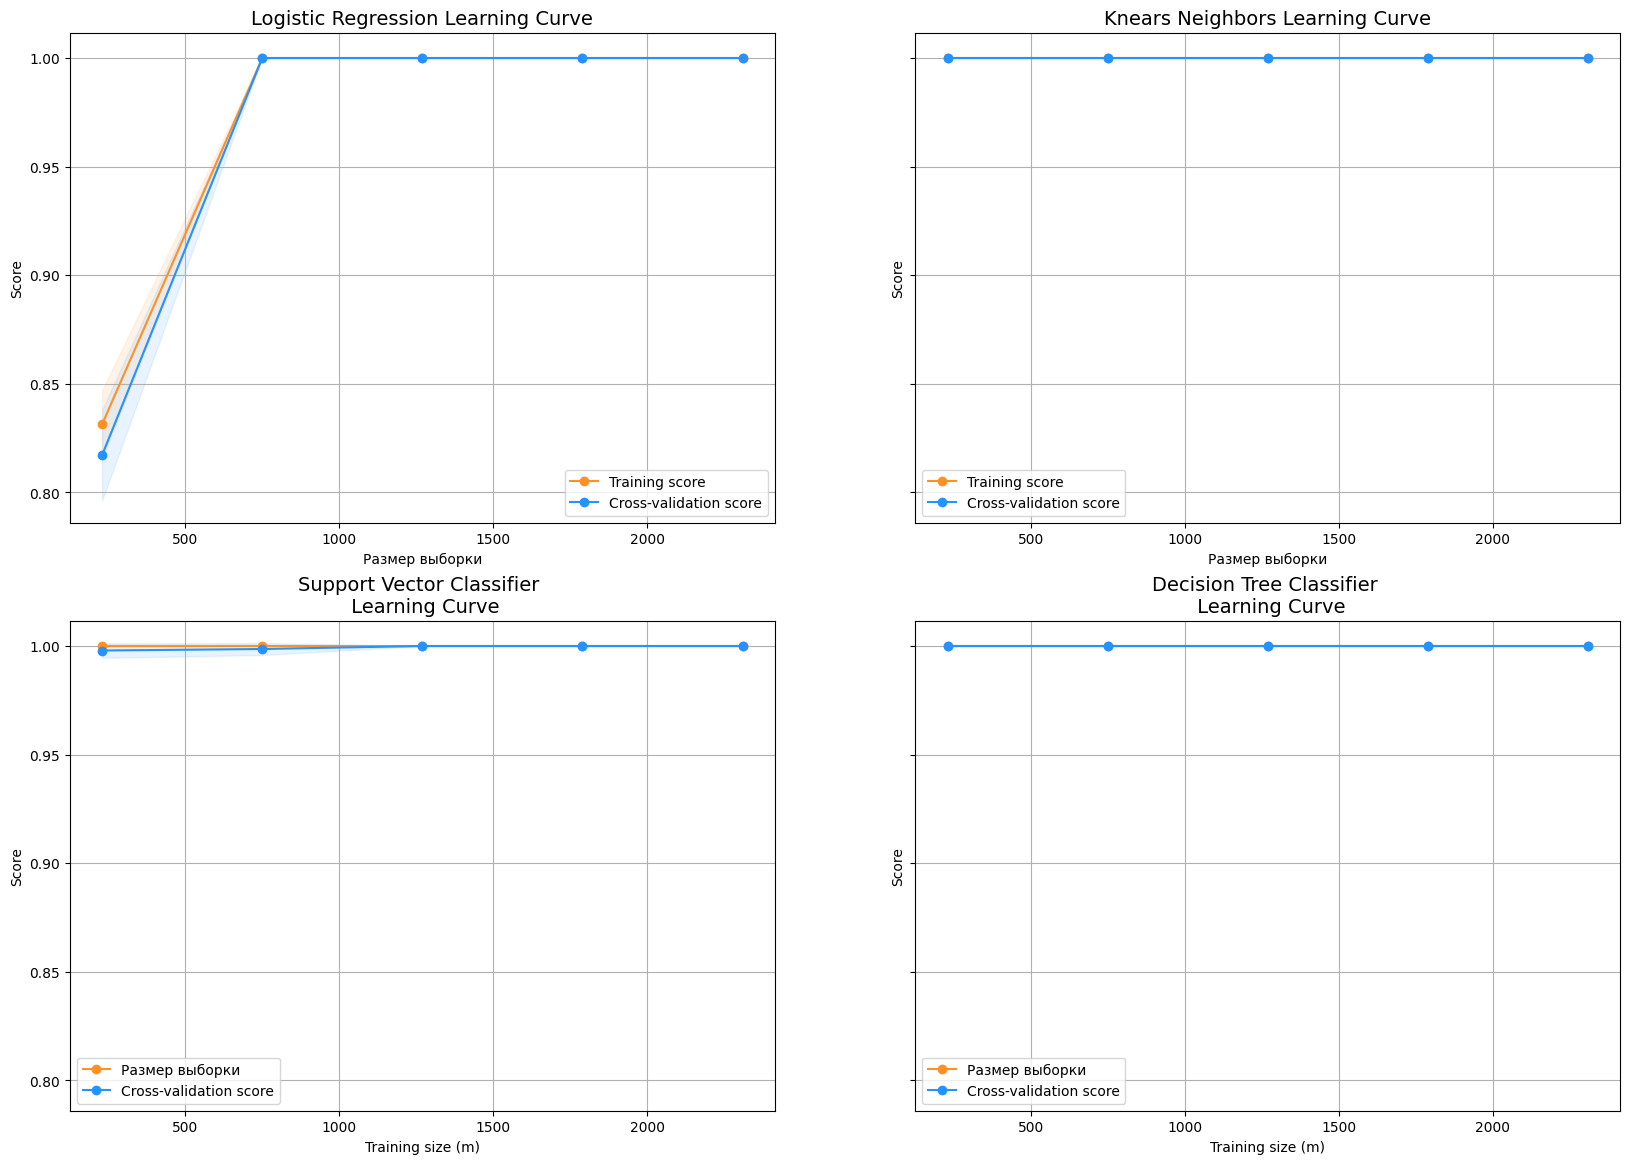

In [77]:
cv = ShuffleSplit(n_splits=100, test_size=0.2, random_state=42)
plot_learning_curves(log_reg, knears_neighbors, svc, tree_clf, X_train, y_train)

In [78]:
from sklearn.model_selection import cross_val_predict

log_reg_pred = cross_val_predict(log_reg, X_train, y_train, cv=5,
                             method="decision_function")

knears_pred = cross_val_predict(knears_neighbors, X_train, y_train, cv=5)

svc_pred = cross_val_predict(svc, X_train, y_train, cv=5,
                             method="decision_function")

tree_pred = cross_val_predict(tree_clf, X_train, y_train, cv=5)

In [80]:
from sklearn.metrics import (precision_score, roc_auc_score, recall_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve, accuracy_score)

print('Logistic Regression: ', roc_auc_score(y_train, log_reg_pred))
print('KNears Neighbors: ', roc_auc_score(y_train, knears_pred))
print('Support Vector Classifier: ', roc_auc_score(y_train, svc_pred))
print('Decision Tree Classifier: ', roc_auc_score(y_train, tree_pred))

Logistic Regression:  1.0
KNears Neighbors:  1.0
Support Vector Classifier:  1.0
Decision Tree Classifier:  1.0


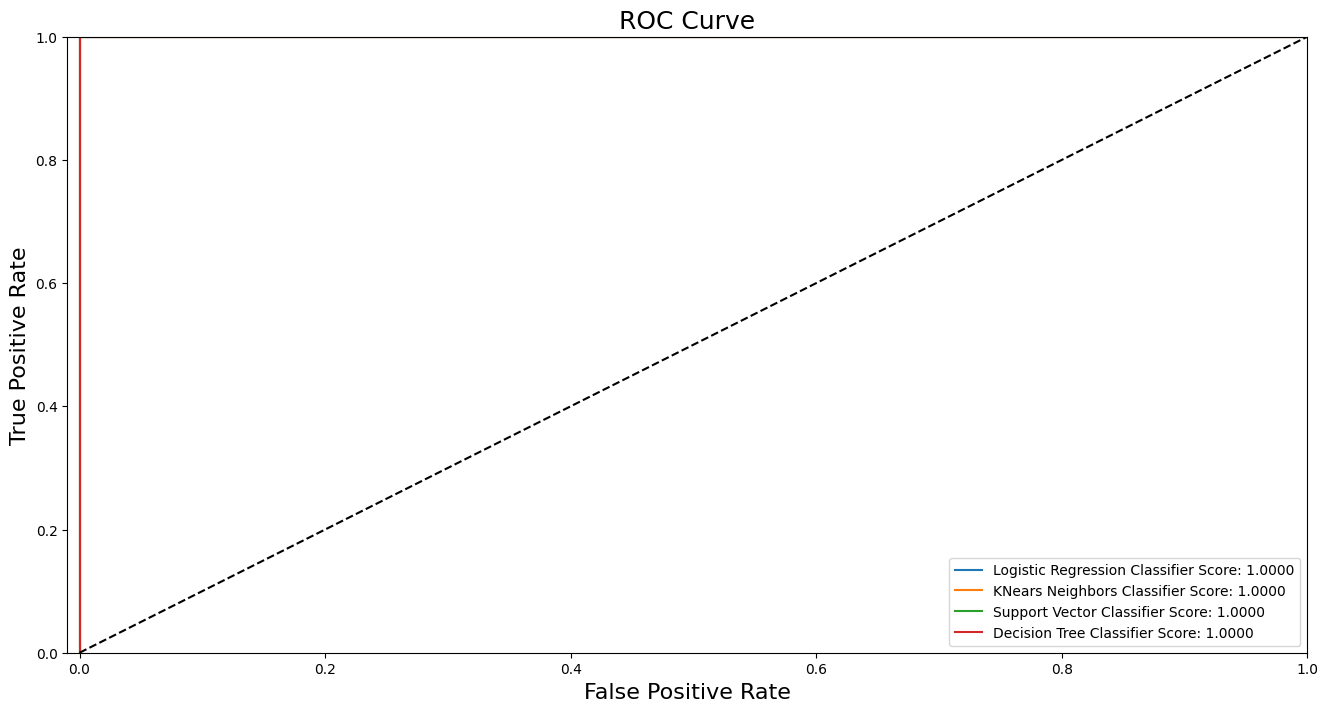

In [81]:
log_fpr, log_tpr, log_thresold = roc_curve(y_train, log_reg_pred)#
knear_fpr, knear_tpr, knear_threshold = roc_curve(y_train, knears_pred)#
svc_fpr, svc_tpr, svc_threshold = roc_curve(y_train, svc_pred)#
tree_fpr, tree_tpr, tree_threshold = roc_curve(y_train, tree_pred)#


def graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr):
    plt.figure(figsize=(16,8))
    plt.title('ROC Curve', fontsize=18)
    plt.plot(log_fpr, log_tpr, label='Logistic Regression Classifier Score: {:.4f}'.format(roc_auc_score(y_train, log_reg_pred)))
    plt.plot(knear_fpr, knear_tpr, label='KNears Neighbors Classifier Score: {:.4f}'.format(roc_auc_score(y_train, knears_pred)))
    plt.plot(svc_fpr, svc_tpr, label='Support Vector Classifier Score: {:.4f}'.format(roc_auc_score(y_train, svc_pred)))
    plt.plot(tree_fpr, tree_tpr, label='Decision Tree Classifier Score: {:.4f}'.format(roc_auc_score(y_train, tree_pred)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.axis([-0.01, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.legend()

graph_roc_curve_multiple(log_fpr, log_tpr, knear_fpr, knear_tpr, svc_fpr, svc_tpr, tree_fpr, tree_tpr)
plt.show()